# Machine Learning Laboratory Experiments
This notebook contains complete modular Python implementations for Experiments 1 through 15.

## Experiment 1: Identifying Data Types and Preprocessing
**Scenario:** A hospital wants to predict whether a patient has diabetes based on demographics and vital signs.

In [1]:
import pandas as pd
import numpy as np

# 1. Load/Create Sample Dataset
data = {
    'Patient_ID': [101, 102, 103, 104, 105],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'Age': [45, 30, 25, 50, 35],
    'Gender': ['Female', 'Male', 'Male', 'Male', 'Female'],
    'Height': [160, 175, 180, 168, 162],
    'Weight': [70, 85, 90, 78, 65],
    'Blood_Pressure': [120, 130, 115, 140, 125],
    'Glucose_Level': [140, 95, 100, 160, 110],
    'Blood_Group': ['A+', 'B+', 'O+', 'AB+', 'A-'],
    'Diabetes': ['Yes', 'No', 'No', 'Yes', 'No']
}
df1 = pd.DataFrame(data)

# 2. Identify Data Types
print("Data Types:\n", df1.dtypes)

# 3. Separate Numerical and Categorical Attributes
num_cols = df1.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df1.select_dtypes(include=['object']).columns.tolist()
print("\nNumerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

# 4. Convert Categorical Variables to Numerical Form (One-Hot / Mapping)
df1['Diabetes_Num'] = df1['Diabetes'].map({'Yes': 1, 'No': 0})
df1_encoded = pd.get_dummies(df1, columns=['Gender', 'Blood_Group'])

# 5. Remove Unnecessary Columns
df1_cleaned = df1_encoded.drop(columns=['Patient_ID', 'Name', 'Diabetes'])

# 6. Display Summary Statistics
print("\nSummary Statistics:\n", df1_cleaned.describe())

# 7. Save Cleaned Dataset
df1_cleaned.to_csv('cleaned_diabetes_data.csv', index=False)
print("\nCleaned dataset saved successfully.")

Data Types:
 Patient_ID         int64
Name              object
Age                int64
Gender            object
Height             int64
Weight             int64
Blood_Pressure     int64
Glucose_Level      int64
Blood_Group       object
Diabetes          object
dtype: object

Numerical Columns: ['Patient_ID', 'Age', 'Height', 'Weight', 'Blood_Pressure', 'Glucose_Level']
Categorical Columns: ['Name', 'Gender', 'Blood_Group', 'Diabetes']

Summary Statistics:
              Age      Height     Weight  Blood_Pressure  Glucose_Level  \
count   5.000000    5.000000   5.000000        5.000000        5.00000   
mean   37.000000  169.000000  77.600000      126.000000      121.00000   
std    10.368221    8.485281  10.310189        9.617692       27.92848   
min    25.000000  160.000000  65.000000      115.000000       95.00000   
25%    30.000000  162.000000  70.000000      120.000000      100.00000   
50%    35.000000  168.000000  78.000000      125.000000      110.00000   
75%    45.000000  1

## Experiment 2: Handling Missing Values
**Scenario:** A retail company collected customer info with missing data due to data entry errors.

In [6]:
import pandas as pd 
import numpy as np 

# Sample Data with Missing Values
data_missing = {
    'CustomerID': [1, 2, 3, 4, 5, 6], 
    'Age': [22, np.nan, 35, 45, np.nan, 28], 
    'Income': [50000, 60000, np.nan, 80000, 52000, np.nan], 
    'Category': ['Electronics', 'Clothing', 'Electronics', np.nan, 'Clothing', 'Clothing'] 
} 

df2 = pd.DataFrame(data_missing) 

# 1 & 2. Detect and Count Missing Values 
print("Missing Values per Column:\n", df2.isnull().sum()) 

df2_cleaned = df2.copy() 

# 3. Replace Numerical Missing Values using Mean (Updated)
df2_cleaned['Age'] = df2_cleaned['Age'].fillna(df2_cleaned['Age'].mean()) 
df2_cleaned['Income'] = df2_cleaned['Income'].fillna(df2_cleaned['Income'].mean()) 

# 4. Replace Categorical Values using Mode (Updated)
df2_cleaned['Category'] = df2_cleaned['Category'].fillna(df2_cleaned['Category'].mode()[0]) 

# 5. Compare Before and After 
print("\n--- Before Cleaning ---\n", df2) 
print("\n--- After Cleaning ---\n", df2_cleaned)

Missing Values per Column:
 CustomerID    0
Age           2
Income        2
Category      1
dtype: int64

--- Before Cleaning ---
    CustomerID   Age   Income     Category
0           1  22.0  50000.0  Electronics
1           2   NaN  60000.0     Clothing
2           3  35.0      NaN  Electronics
3           4  45.0  80000.0          NaN
4           5   NaN  52000.0     Clothing
5           6  28.0      NaN     Clothing

--- After Cleaning ---
    CustomerID   Age   Income     Category
0           1  22.0  50000.0  Electronics
1           2  32.5  60000.0     Clothing
2           3  35.0  60500.0  Electronics
3           4  45.0  80000.0     Clothing
4           5  32.5  52000.0     Clothing
5           6  28.0  60500.0     Clothing


## Experiment 3: Encoding Categorical Variables
**Scenario:** Predicting employee salaries using categorical variables (Gender, Department, Education).

In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

data_emp = {
    'Gender': ['Male', 'Female', 'Female', 'Male'],
    'Department': ['HR', 'IT', 'Finance', 'IT'],
    'Education': ['Bachelors', 'Masters', 'PhD', 'Bachelors'],
    'Experience': [2, 5, 8, 3],
    'Salary': [50000, 75000, 110000, 60000]
}
df3 = pd.DataFrame(data_emp)

# 1. Identify Categorical Columns
cat_cols = ['Gender', 'Department', 'Education']

# 2. Apply Label Encoding
df3_label = df3.copy()
le = LabelEncoder()
for col in cat_cols:
    df3_label[col + '_LE'] = le.fit_transform(df3_label[col])

# 3. Apply One-Hot Encoding
df3_ohe = pd.get_dummies(df3, columns=cat_cols)

print("Label Encoded Data:\n", df3_label[['Gender_LE', 'Department_LE', 'Education_LE']])
print("\nOne-Hot Encoded Data:\n", df3_ohe.head())
# Explanation: Label Encoding fits ordinal relationships (like Education), while One-Hot avoids ordering bias for nominal categories (like Department).

Label Encoded Data:
    Gender_LE  Department_LE  Education_LE
0          1              1             0
1          0              2             1
2          0              0             2
3          1              2             0

One-Hot Encoded Data:
    Experience  Salary  Gender_Female  Gender_Male  Department_Finance  \
0           2   50000          False         True               False   
1           5   75000           True        False               False   
2           8  110000           True        False                True   
3           3   60000          False         True               False   

   Department_HR  Department_IT  Education_Bachelors  Education_Masters  \
0           True          False                 True              False   
1          False           True                False               True   
2          False          False                False              False   
3          False           True                 True              False   

   

## Experiment 4: Feature Scaling
**Scenario:** Scaling features for loan approval prediction.

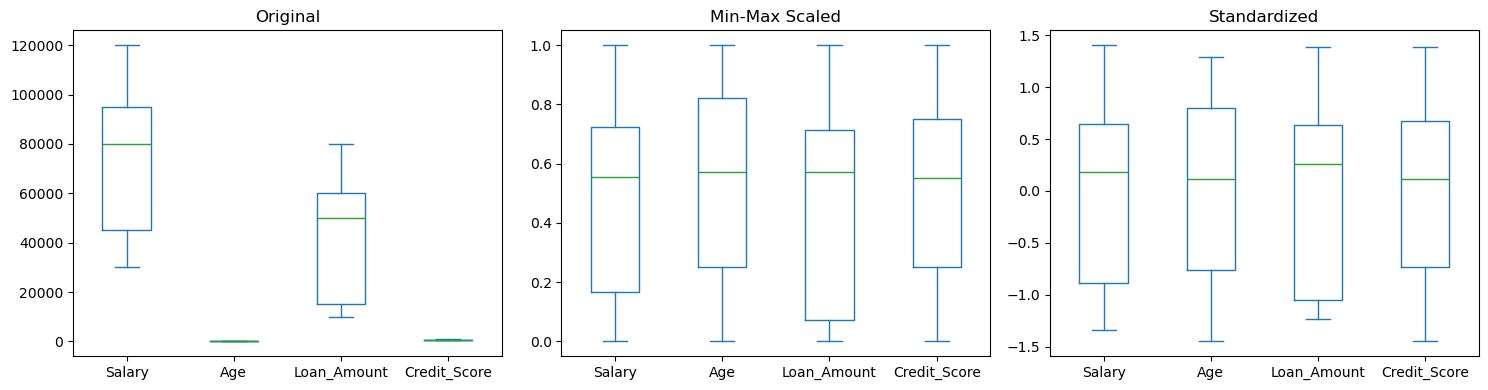

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

data_bank = {
    'Salary': [30000, 80000, 120000, 45000, 95000],
    'Age': [22, 45, 50, 29, 38],
    'Loan_Amount': [10000, 50000, 80000, 15000, 60000],
    'Credit_Score': [600, 750, 800, 650, 710]
}
df4 = pd.DataFrame(data_bank)

# 1. Min-Max Scaling
min_max_scaler = MinMaxScaler()
df4_minmax = pd.DataFrame(min_max_scaler.fit_transform(df4), columns=df4.columns)

# 2. Standardization
std_scaler = StandardScaler()
df4_std = pd.DataFrame(std_scaler.fit_transform(df4), columns=df4.columns)

# 3 & 4. Plot Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df4.plot(kind='box', ax=axes[0], title='Original')
df4_minmax.plot(kind='box', ax=axes[1], title='Min-Max Scaled')
df4_std.plot(kind='box', ax=axes[2], title='Standardized')
plt.tight_layout()
plt.show()

## Experiment 5: Dimensionality Reduction using PCA
**Scenario:** Reducing high-dimensional image features using Principal Component Analysis.

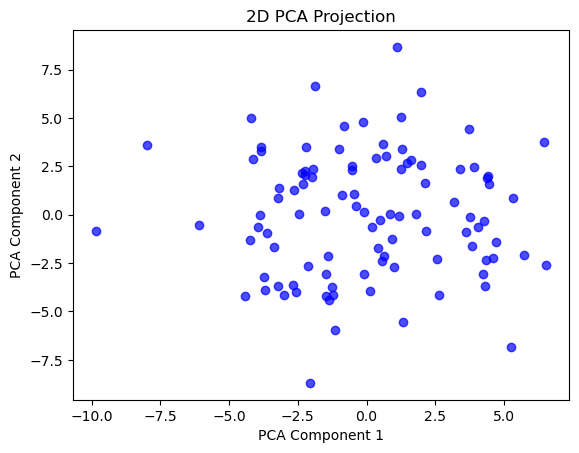

Explained Variance Ratio: [0.02045208 0.02013102]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Generate Synthetic Data (100 samples, 500 features)
X = np.random.rand(100, 500)

# 2. Standardize Data
X_std = StandardScaler().fit_transform(X)

# 3 & 4. Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

# 5. Plot Transformed Data
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('2D PCA Projection')
plt.show()

# 6. Calculate Explained Variance Ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

## Experiment 6: Feature Selection
**Scenario:** Selecting top medical features for disease prediction using `SelectKBest`.

In [10]:
from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Synthetic dataset with 100 features
X, y = make_classification(n_samples=200, n_features=100, n_informative=15, random_state=42)

# Fixed line below: replaced 'test_state' with 'random_state'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# Accuracy before feature selection
clf = LogisticRegression().fit(X_train, y_train)
acc_before = accuracy_score(y_test, clf.predict(X_test))

# 1 & 2. Apply SelectKBest (Top 10 Features)
selector = SelectKBest(score_func=f_classif, k=10)
X_train_k = selector.fit_transform(X_train, y_train)
X_test_k = selector.transform(X_test)

# Accuracy after feature selection
clf_k = LogisticRegression().fit(X_train_k, y_train)
acc_after = accuracy_score(y_test, clf_k.predict(X_test_k))

print(f"Accuracy before Feature Selection: {acc_before:.2f}")
print(f"Accuracy after Selecting Top 10 Features: {acc_after:.2f}")

Accuracy before Feature Selection: 0.78
Accuracy after Selecting Top 10 Features: 0.65


## Experiment 7: Simple Linear Regression
**Scenario:** Predicting house prices based on house area.

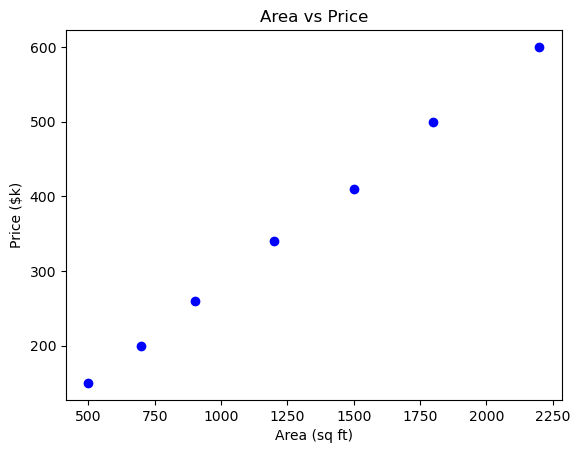

Predicted price for 1400 sq ft: $389.37k
MAE: 3.3056057866184574
MSE: 13.670886075949442
R² Score: 0.9993992166657206


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dataset
area = np.array([500, 700, 900, 1200, 1500, 1800, 2200]).reshape(-1, 1)
price = np.array([150, 200, 260, 340, 410, 500, 600])

# 2. Plot Area vs Price
plt.scatter(area, price, color='blue')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price ($k)')
plt.title('Area vs Price')
plt.show()

# 3. Train Linear Regression Model
model = LinearRegression()
model.fit(area, price)

# 4. Predict for new house (e.g. 1400 sq ft)
pred_price = model.predict([[1400]])
print(f"Predicted price for 1400 sq ft: ${pred_price[0]:.2f}k")

# 5. Calculate Metrics
y_pred = model.predict(area)
print("MAE:", mean_absolute_error(price, y_pred))
print("MSE:", mean_squared_error(price, y_pred))
print("R² Score:", r2_score(price, y_pred))

## Experiment 8: Student Marks Prediction
**Scenario:** Predicting exam scores based on study hours.

Predicted Marks for 5 Hours: 64.51
Predicted Marks for 7 Hours: 79.04
Predicted Marks for 10 Hours: 100.85


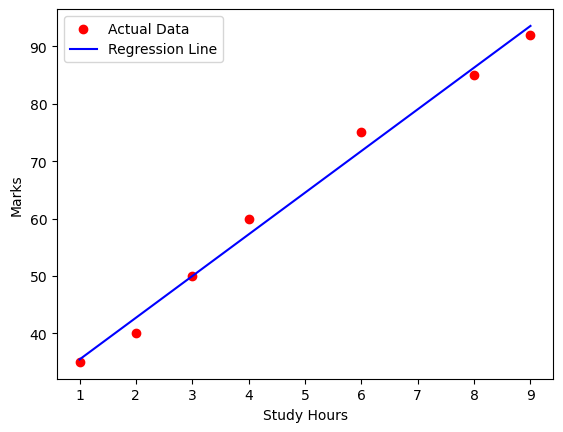

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data
hours = np.array([1, 2, 3, 4, 6, 8, 9]).reshape(-1, 1)
marks = np.array([35, 40, 50, 60, 75, 85, 92])

# Train Model
reg = LinearRegression().fit(hours, marks)

# Predict for 5, 7, and 10 Hours
test_hours = np.array([[5], [7], [10]])
predictions = reg.predict(test_hours)
for h, p in zip([5, 7, 10], predictions):
    print(f"Predicted Marks for {h} Hours: {p:.2f}")

# Plot Regression Line
plt.scatter(hours, marks, color='red', label='Actual Data')
plt.plot(hours, reg.predict(hours), color='blue', label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.legend()
plt.show()

## Experiment 9: Multiple Linear Regression
**Scenario:** Predicting house prices using Area, Bedrooms, and Age.

In [13]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

data_house = {
    'Area': [1000, 1500, 1800, 2400, 3000],
    'Bedrooms': [2, 3, 3, 4, 4],
    'Age': [10, 5, 15, 2, 8],
    'Price': [250, 380, 400, 550, 620]
}
df9 = pd.DataFrame(data_house)
X = df9[['Area', 'Bedrooms', 'Age']]
y = df9['Price']

# Train Model
mlr = LinearRegression().fit(X, y)
print("Coefficients:", dict(zip(X.columns, mlr.coef_)))
print("Intercept:", mlr.intercept_)

# Predict & Evaluate
y_pred = mlr.predict(X)
comp = pd.DataFrame({'Actual': y, 'Predicted': y_pred})
print("\nActual vs Predicted:\n", comp)

Coefficients: {'Area': np.float64(0.12749224634470585), 'Bedrooms': np.float64(54.990031014621124), 'Age': np.float64(-1.5496233938856916)}
Intercept: 29.093929995568544

Actual vs Predicted:
    Actual   Predicted
0     250  251.070004
1     380  377.554276
2     400  400.305716
3     550  551.936198
4     620  619.133806


## Experiment 10: Sales Prediction
**Scenario:** Predicting monthly sales based on advertising channels (TV, Radio, Newspaper).

In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

np.random.seed(42)
df10 = pd.DataFrame({
    'TV': np.random.randint(50, 300, 50),
    'Radio': np.random.randint(10, 50, 50),
    'Newspaper': np.random.randint(5, 40, 50),
})
df10['Sales'] = 0.05 * df10['TV'] + 0.18 * df10['Radio'] + 0.01 * df10['Newspaper'] + 5

X = df10[['TV', 'Radio', 'Newspaper']]
y = df10['Sales']

# 1. Train Multiple Linear Regression
model10 = LinearRegression().fit(X, y)

# 2. Identify Most Important Feature
importance = pd.Series(model10.coef_, index=X.columns)
print("Feature Coefficients:\n", importance)
print("Most Important Feature:", importance.idxmax())

# 3 & 4. Predict & Evaluate
y_pred = model10.predict(X)
print(f"RMSE: {root_mean_squared_error(y, y_pred):.2f}")
print(f"R2 Score: {r2_score(y, y_pred):.2f}")

Feature Coefficients:
 TV           0.05
Radio        0.18
Newspaper    0.01
dtype: float64
Most Important Feature: Radio
RMSE: 0.00
R2 Score: 1.00


## Experiment 11: Complete Machine Learning Pipeline
**Scenario:** Full end-to-end pipeline for predicting employee salaries.

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Sample Data
df11 = pd.DataFrame({
    'Age': [25, 30, 45, 35, None, 50],
    'Gender': ['M', 'F', 'F', 'M', 'F', 'M'],
    'Education': ['Bachelors', 'Masters', 'PhD', 'Bachelors', 'Masters', 'PhD'],
    'Experience': [2, 5, 12, 7, 8, 20],
    'City': ['NY', 'SF', 'NY', 'LA', 'SF', 'LA'],
    'Salary': [50000, 70000, 120000, 80000, 90000, 150000]
})

X = df11.drop(columns=['Salary'])
y = df11['Salary']

# Preprocessing Steps
num_features = ['Age', 'Experience']
cat_features = ['Gender', 'Education', 'City']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Complete Pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', LinearRegression())])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)

print("Pipeline Evaluation R²:", r2_score(y_test, preds))

Pipeline Evaluation R²: 0.1586904358753637


## Experiment 12: Smart Agriculture
**Scenario:** Predicting crop yield using soil and climate data.

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

crop_data = {
    'Temperature': [25, 28, 30, 22, 27],
    'Rainfall': [200, 150, 100, 250, 180],
    'Humidity': [70, 65, 60, 80, 75],
    'Soil_pH': [6.5, 6.8, 7.2, 6.0, 6.6],
    'Fertilizer': [50, 60, 40, 70, 55],
    'Soil_Type': ['Clay', 'Sandy', 'Loam', 'Clay', 'Loam'],
    'Yield': [4.2, 3.8, 3.1, 4.8, 4.0]
}
df12 = pd.DataFrame(crop_data)

# Encode categorical Soil_Type
df12_encoded = pd.get_dummies(df12, columns=['Soil_Type'])

X = df12_encoded.drop(columns=['Yield'])
y = df12_encoded['Yield']

model12 = LinearRegression().fit(X, y)
print("Crop Yield Model Trained. Model R2 Score:", model12.score(X, y))

Crop Yield Model Trained. Model R2 Score: 1.0


## Experiment 13: Wine Quality Prediction
**Scenario:** Predicting wine quality based on chemical properties.

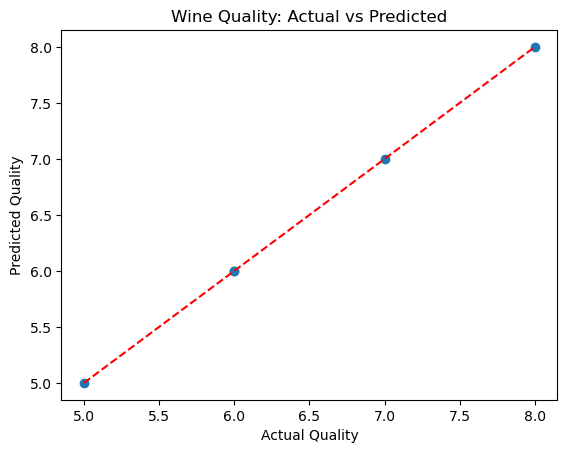

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

wine_data = {
    'Alcohol': [10.5, 12.0, 11.2, 9.8, 13.1],
    'Sugar': [2.1, 1.5, 3.0, 5.2, 1.2],
    'pH': [3.2, 3.4, 3.1, 3.5, 3.0],
    'Density': [0.996, 0.994, 0.997, 0.999, 0.992],
    'Sulphates': [0.56, 0.68, 0.50, 0.45, 0.75],
    'Quality_Score': [6, 7, 6, 5, 8]
}
df13 = pd.DataFrame(wine_data)

# 1. EDA & Feature Scaling
X = df13.drop(columns=['Quality_Score'])
y = df13['Quality_Score']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train & Evaluate Linear Regression
model13 = LinearRegression().fit(X_scaled, y)
preds = model13.predict(X_scaled)

# Visualize Predictions
plt.scatter(y, preds)
plt.plot([min(y), max(y)], [min(y), max(y)], '--', color='red')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Wine Quality: Actual vs Predicted')
plt.show()

## Experiment 14: Student Performance Analysis
**Scenario:** Analyzing feature importance to identify key drivers of student performance.

In [18]:
import pandas as pd
from sklearn.linear_model import LinearRegression

student_df = pd.DataFrame({
    'Attendance': [85, 90, 60, 95, 70],
    'Internal_Marks': [20, 23, 12, 25, 15],
    'Assignment_Marks': [18, 19, 10, 20, 14],
    'Study_Hours': [4, 6, 2, 7, 3],
    'Final_Marks': [78, 88, 50, 94, 62]
})

X = student_df.drop(columns=['Final_Marks'])
y = student_df['Final_Marks']

# Train MLR Model
model14 = LinearRegression().fit(X, y)

# Interpret Coefficients
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model14.coef_
}).sort_values(by='Coefficient', ascending=False)

print("Feature Importance:\n", importance)

Feature Importance:
             Feature   Coefficient
1    Internal_Marks  4.000000e+00
2  Assignment_Marks  2.000000e+00
3       Study_Hours  6.891456e-15
0        Attendance -8.000000e-01


## Experiment 15: End-to-End Mini Project (Sales Prediction)
**Scenario:** E-commerce sales prediction using full ML project workflows.

--- Evaluation Metrics ---
MAE: 267.3425062111933
MSE: 111516.37330074781
RMSE: 333.9406733249902
R² Score: 0.08966225876940559


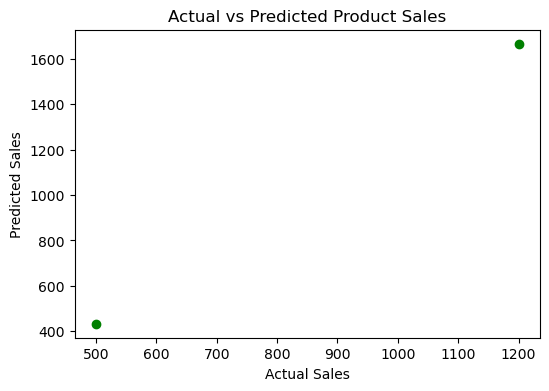

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Create Dataset
data_sales = {
    'Product_Category': ['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Home'],
    'Product_Price': [200, 50, 500, 150, 80, 300],
    'Discount': [10, 5, 15, 10, 0, 20],
    'Advertisement_Cost': [500, 200, 1000, 300, 150, 600],
    'Customer_Rating': [4.5, 4.0, 4.8, 3.9, 4.1, 4.3],
    'Sales': [1200, 500, 2500, 800, 400, 1500]
}
df15 = pd.DataFrame(data_sales)

# 2 & 3. One-Hot Encoding Categorical Data
df15_prep = pd.get_dummies(df15, columns=['Product_Category'])

# 4. Feature and Target Split
X = df15_prep.drop(columns=['Sales'])
y = df15_prep['Sales']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaling Numerical Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train Linear Regression Model
model15 = LinearRegression().fit(X_train_scaled, y_train)
y_pred = model15.predict(X_test_scaled)

# 7. Model Evaluation
print("--- Evaluation Metrics ---")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

# 9. Visualize Actual vs Predicted Sales
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, color='green')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Product Sales')
plt.show()